# Proyek Prediksi Harga Komoditas Pertanian
## Alur Kerja Proyek

## 1. Setup Environment
- Instalasi library yang diperlukan (RAPIDS, TensorFlow, dll)
- Import library yang diperlukan

# Load Library

In [1]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting

# Machine Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Evaluation Metrics
from cuml.metrics import regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Print library versions
print(f"cuDF Version: {cudf.__version__}")
print(f"CuPy Version: {cp.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# GPU Check
from numba import cuda

if cuda.is_available():
    print("\nGPU Detected:")
    device = cuda.get_current_device()
    print(f"Device Name: {device.name}") 
else:
    print("Warning: No GPU detected - Falling back to CPU mode")

2025-07-13 23:53:24.131296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-13 23:53:24.167191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-13 23:53:24.198096: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-13 23:53:24.208108: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-13 23:53:24.241181: I tensorflow/core/platform/cpu_feature_guar

cuDF Version: 24.10.01
CuPy Version: 13.3.0
TensorFlow Version: 2.17.0

GPU Detected:
Device Name: b'NVIDIA GeForce RTX 4050 Laptop GPU'


## 2. Data Understanding
- Load dataset (Harga.csv dan Triwulan.csv)
- Lakukan eksplorasi data (lihat beberapa baris pertama, cek missing values)

# Load Dataset

In [2]:
def load_datasets():
    """
    Memuat dataset Harga.csv dan Triwulan.csv dengan cudf.
    Mengembalikan tuple (harga_df, triwulan_df).
    """
    try:
        # Load Harga.csv (data harian)
        harga_df = cudf.read_csv('harga.csv', parse_dates=['Tanggal'], skipinitialspace=True)
        
        # Load Triwulan.csv (data produksi)
        triwulan_df = cudf.read_csv('produksi.csv', skipinitialspace=True)
        
        # Validasi keberadaan kolom penting
        required_harga_cols = {'Komoditi', 'Tanggal', ' Harga Petani ', ' Harga Pengecer '}
        required_triwulan_cols = {'Komoditi', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas', 'Produksi'}
        
        assert required_harga_cols.issubset(harga_df.columns), "Kolom tidak valid di Harga.csv"
        assert required_triwulan_cols.issubset(triwulan_df.columns), "Kolom tidak valid di Triwulan.csv"
        
        print("✔ Dataset berhasil dimuat")
        print(f"- Harga.csv: {len(harga_df)} baris")
        print(f"- Triwulan.csv: {len(triwulan_df)} baris")
        
        return harga_df, triwulan_df
    
    except FileNotFoundError as e:
        print(f"❌ File tidak ditemukan: {e}")
        return None, None
    except Exception as e:
        print(f"❌ Error saat memuat dataset: {e}")
        return None, None

# Contoh penggunaan
harga_df, triwulan_df = load_datasets()

if harga_df is not None:
    print("\n5 baris pertama harga.csv:")
    print(harga_df.head())

if triwulan_df is not None:
    print("\n5 baris pertama Produksi.csv:")
    print(triwulan_df.head())

✔ Dataset berhasil dimuat
- Harga.csv: 4382 baris
- Triwulan.csv: 30 baris

5 baris pertama harga.csv:
              Komoditi    Tanggal   Harga Petani    Harga Pengecer 
0  Jagung Pipil Kering 2022-01-03            4800              5000
1  Jagung Pipil Kering 2022-01-04            4800              5000
2  Jagung Pipil Kering 2022-01-05            4800              5000
3  Jagung Pipil Kering 2022-01-06            4800              5000
4  Jagung Pipil Kering 2022-01-07            4800              5000

5 baris pertama Produksi.csv:
     Komoditi  tahun  triwulan  Luas Panen  Produktivitas   Produksi
0  Padi sawah   2022         1  35685.6200      56.593625  201957.86
1  Padi sawah   2022         2  12599.0000      54.279752   68387.06
2  Padi sawah   2022         3   6888.7897      55.240632   38054.11
3  Padi sawah   2023         1  26790.3606      55.977470  149965.66
4  Padi sawah   2023         2  21687.8044      58.797478  127518.82


In [3]:
harga_df = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

# EDA (Exploration Data Analysis)



In [4]:
def explore_harga_data(harga_df):
    """
    Melakukan eksplorasi data pada DataFrame harga_df.
    """
    # 1. Cek kolom dan tipe data
    print("1. Kolom dan Tipe Data:")
    print(harga_df.dtypes)
    print("\n")

    # 2. Cek data duplikat
    duplicate_count = harga_df.duplicated().sum()
    print(f"2. Jumlah Data Duplikat: {duplicate_count}")
    print("\n")

    # 3. Cek missing values
    missing_values = harga_df.isnull().sum()
    print("3. Missing Values:")
    print(missing_values[missing_values > 0])  # Hanya tampilkan kolom dengan missing values
    print("\n")

    # 4. Ringkasan Statistik untuk Data Numerik
    print("4. Ringkasan Statistik (Data Numerik):")
    print(harga_df.describe())
    print("\n")

    # 5. Ringkasan Statistik untuk Data Kategorikal
    print("5. Ringkasan Statistik (Data Kategorikal):")
    categorical_summary = harga_df.describe(include=['object', 'category'])
    print(categorical_summary)
    print("\n")

Data Harga

In [5]:
explore_harga_data(harga_df)

1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      1440
Harga Pengecer    1439
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer
count                           4382   2942.000000     2943.000000
mean   2023-07-02 17:59:30.424463616   9954.928620    11163.098879
min              2022-01-01 00:00:00   3300.000000     3600.000000
25%    2022-10-02 00:00:00.000000000   8200.000000     9000.000000
50%    2023-07-03 00:00:00.000000000  10500.000000    11500.000000
75%    2024-04-01 18:00:00.000000000  13000.000000    15000.000000
max              2024-12-31 00:00:00  15500.000000    17500.000000
std                             <NA>   3580.475149     4344.181100


5. Ringkasan Statistik (Data Kategorikal):
            Komoditi
count      

EDA Singkat dataset harga


🧹 Membersihkan data...

🔍 Inspeksi Dasar:
Dimensi Data: (4382, 4)

Tipe Data:
 Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani             float64
Harga Pengecer           float64
dtype: object

5 Sample Data:
               Komoditi    Tanggal  Harga Petani  Harga Pengecer
0  Jagung Pipil Kering 2022-01-03        4800.0          5000.0
1  Jagung Pipil Kering 2022-01-04        4800.0          5000.0
2  Jagung Pipil Kering 2022-01-05        4800.0          5000.0
3  Jagung Pipil Kering 2022-01-06        4800.0          5000.0
4  Jagung Pipil Kering 2022-01-07        4800.0          5000.0

❓ Missing Values:
Harga Petani      1440
Harga Pengecer    1439
dtype: int64

♻ Data Duplikat: 0

📊 Statistical Summary (Numerical):
                             Tanggal  Harga Petani  Harga Pengecer
count                           4382   2942.000000     2943.000000
mean   2023-07-02 17:59:30.424463616   9954.928620    11163.098879
min              2022-01-01 00:00:00  

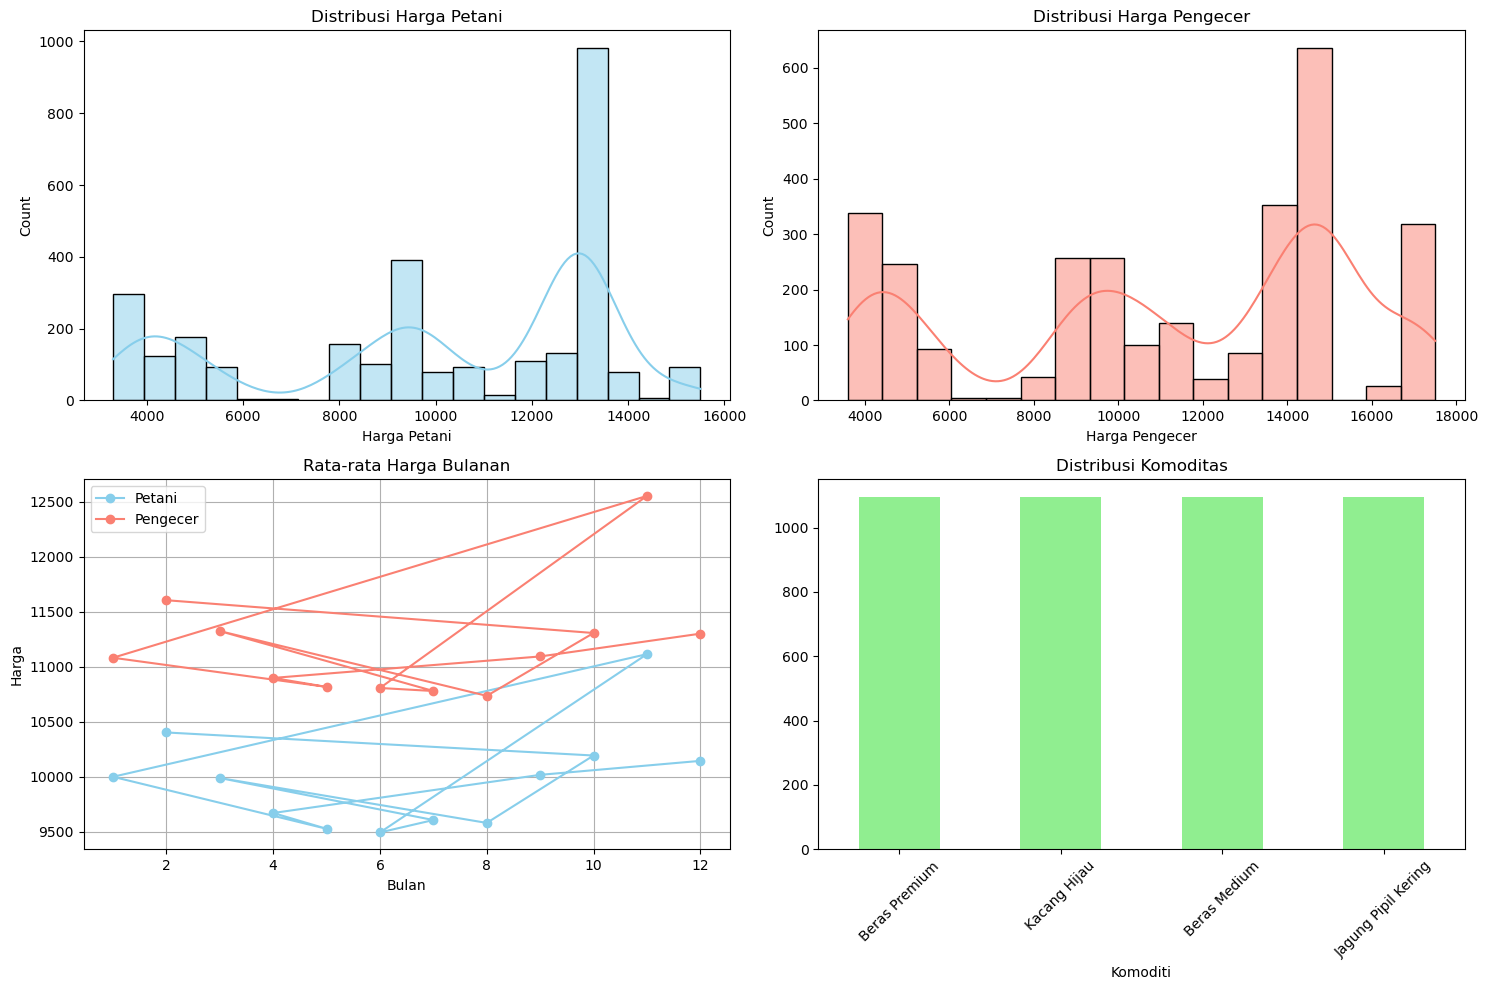

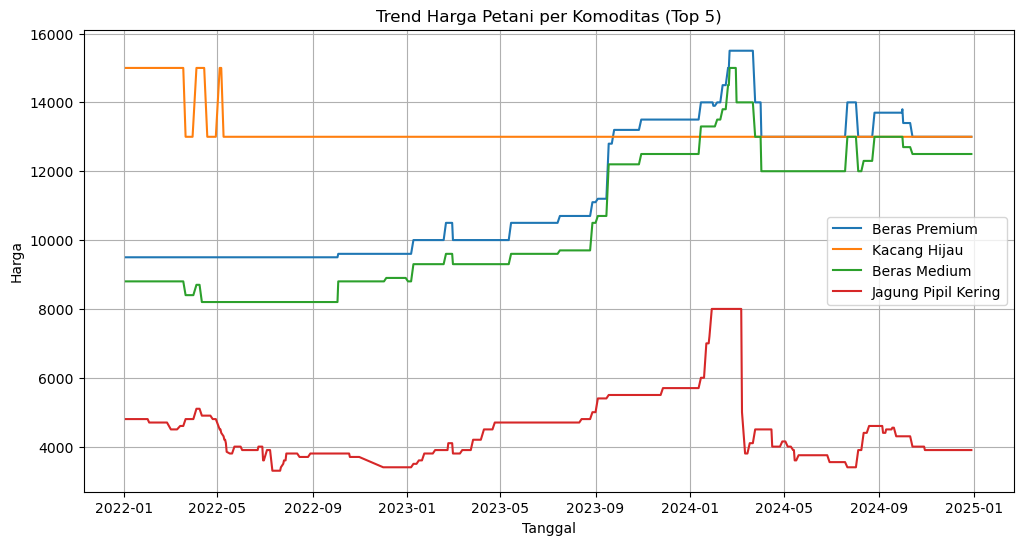

In [6]:

def clean_price_column(series):
    # Pastikan kolom diubah menjadi string
    series = series.astype(str)
    return (
        series.str.replace('Rp', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .astype(float)
    )

# 2. Data Cleaning
print("\n🧹 Membersihkan data...")
for col in ['Harga Petani', 'Harga Pengecer']:
    harga_df[col] = clean_price_column(harga_df[col])

#3. Basic Inspection
print("\n🔍 Inspeksi Dasar:")
print("Dimensi Data:", harga_df.shape)
print("\nTipe Data:\n", harga_df.dtypes)
print("\n5 Sample Data:\n", harga_df.head())

# 4. Check Missing Values
print("\n❓ Missing Values:")
missing_values = harga_df.isnull().sum()
print(missing_values[missing_values > 0])

# 5. Check Duplicates
print("\n♻ Data Duplikat:", harga_df.duplicated().sum())

# 6. Statistical Summary
print("\n📊 Statistical Summary (Numerical):")
print(harga_df.describe())

# 7. Categorical Analysis
print("\n📊 Statistical Summary (Categorical):")
print(harga_df['Komoditi'].describe())

# ========= VISUALIZATION =========
plt.figure(figsize=(15, 10))

# 8. Price Distribution
plt.subplot(2, 2, 1)
sns.histplot(harga_df['Harga Petani'].to_pandas(), kde=True, color='skyblue')
plt.title('Distribusi Harga Petani')

plt.subplot(2, 2, 2)
sns.histplot(harga_df['Harga Pengecer'].to_pandas(), kde=True, color='salmon')
plt.title('Distribusi Harga Pengecer')

# 9. Price Trends
harga_df['Bulan'] = harga_df['Tanggal'].dt.month
monthly_avg = harga_df.groupby('Bulan')[['Harga Petani', 'Harga Pengecer']].mean()

plt.subplot(2, 2, 3)
monthly_avg['Harga Petani'].to_pandas().plot(marker='o', color='skyblue')
monthly_avg['Harga Pengecer'].to_pandas().plot(marker='o', color='salmon')
plt.title('Rata-rata Harga Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Harga')
plt.legend(['Petani', 'Pengecer'])
plt.grid(True)

# 10. Commodity Analysis
plt.subplot(2, 2, 4)
harga_df['Komoditi'].value_counts().to_pandas().plot(kind='bar', color='lightgreen')
plt.title('Distribusi Komoditas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 11. Price Comparison by Commodity
plt.figure(figsize=(12, 6))
top_commodities = harga_df['Komoditi'].value_counts().head(5).index.to_pandas()

for commodity in top_commodities:
    subset = harga_df[harga_df['Komoditi'] == commodity]
    sns.lineplot(
        x=subset['Tanggal'].to_pandas(),
        y=subset['Harga Petani'].to_pandas(),
        label=commodity
    )

plt.title('Trend Harga Petani per Komoditas (Top 5)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()

Boxplot dataset Harga

Menunjukkan persebaran data dalam dataset harga

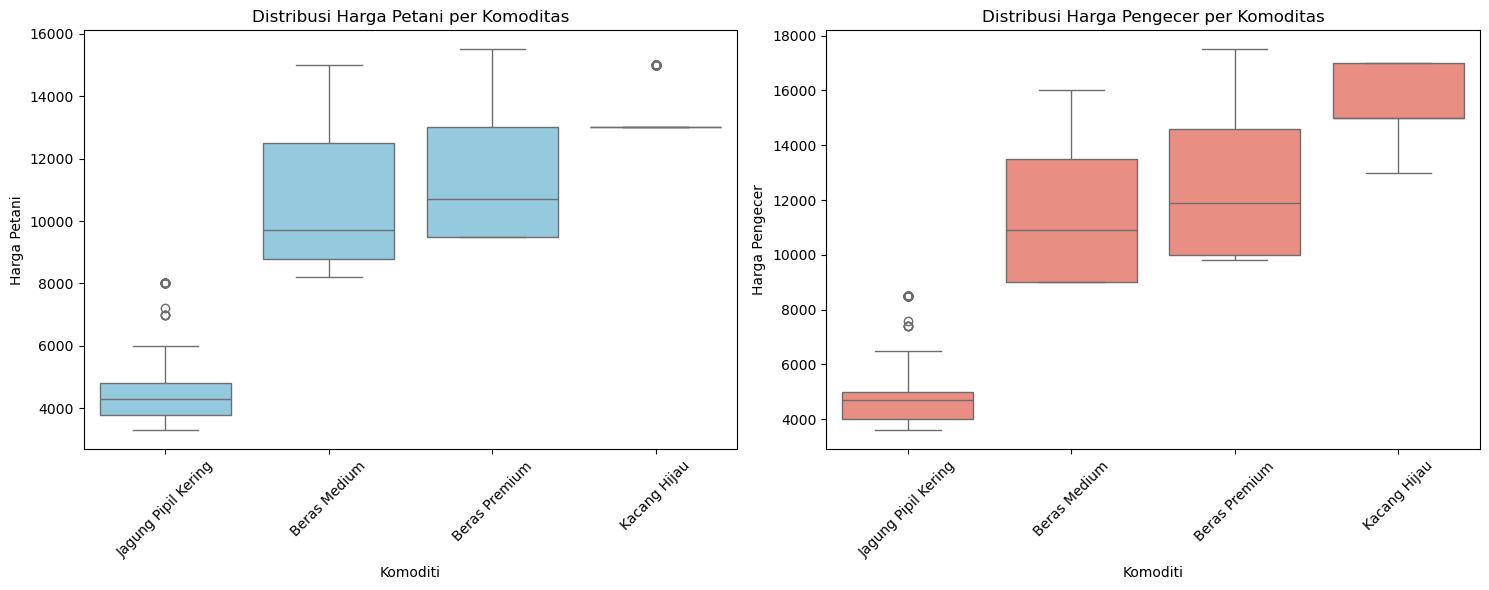

In [7]:
plt.figure(figsize=(15, 6))

# Boxplot Harga Petani per Komoditas
plt.subplot(1, 2, 1)
sns.boxplot(data=harga_df.to_pandas(), 
           x='Komoditi', y='Harga Petani',
           color='skyblue')
plt.title('Distribusi Harga Petani per Komoditas')
plt.xticks(rotation=45)

# Boxplot Harga Pengecer per Komoditas
plt.subplot(1, 2, 2)
sns.boxplot(data=harga_df.to_pandas(), 
           x='Komoditi', y='Harga Pengecer',
           color='salmon')
plt.title('Distribusi Harga Pengecer per Komoditas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

History bar dataset harga

Menunjukkan tren dari harga per komoditas

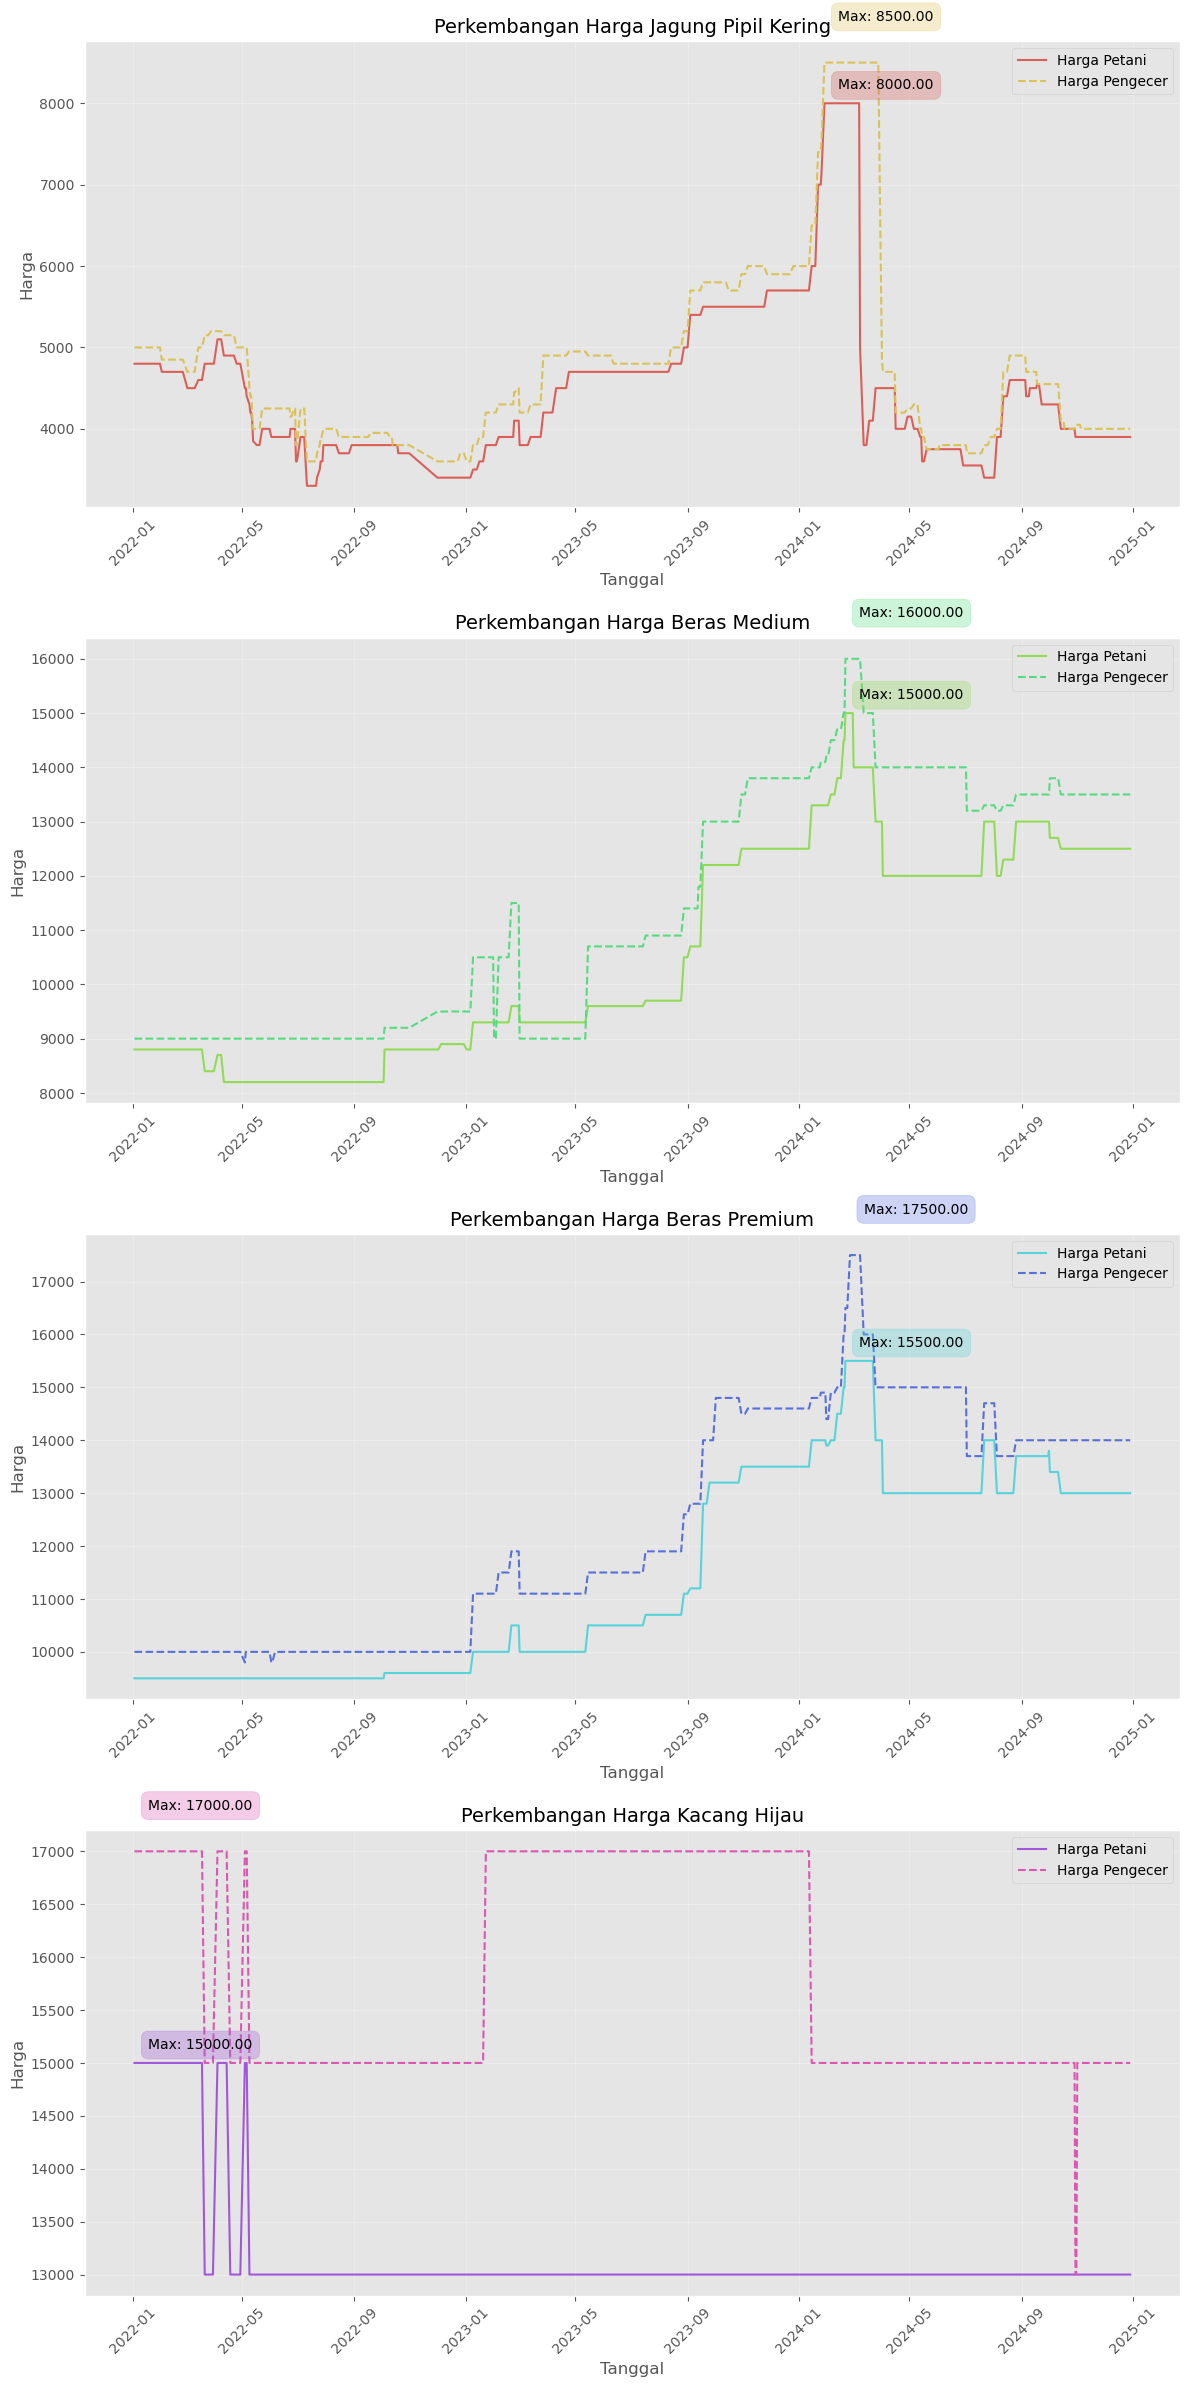

In [8]:
# Custom style
plt.style.use('ggplot')
colors = sns.color_palette("hls", 8)  # 8 warna berbeda untuk komoditas

# Daftar komoditas unik
komoditas_list = harga_df['Komoditi'].unique().to_pandas()

# Buat figure dengan subplot untuk setiap komoditas
fig, axes = plt.subplots(len(komoditas_list), 1, figsize=(12, 6*len(komoditas_list)))

# Plot per komoditas
for idx, komod in enumerate(komoditas_list):
    ax = axes[idx] if len(komoditas_list) > 1 else axes
    subset = harga_df[harga_df['Komoditi'] == komod]
    
    # Line plot
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Petani', 
                 label='Harga Petani', color=colors[idx*2], ax=ax)
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Pengecer', 
                 label='Harga Pengecer', color=colors[idx*2+1], linestyle='--', ax=ax)
    
    # Annotasi titik maksimum untuk Harga Petani
    max_petani = subset['Harga Petani'].max()
    max_date_petani = subset[subset['Harga Petani'] == max_petani]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_petani:.2f}', 
                 xy=(max_date_petani, max_petani),
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2]))
    
    # Annotasi titik maksimum untuk Harga Pengecer
    max_pengecer = subset['Harga Pengecer'].max()
    max_date_pengecer = subset[subset['Harga Pengecer'] == max_pengecer]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_pengecer:.2f}', 
                 xy=(max_date_pengecer, max_pengecer),
                 xytext=(10, 30), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2+1]))
    
    # Customisasi plot
    ax.set_title(f'Perkembangan Harga {komod}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=12)
    ax.set_ylabel('Harga', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotasi label tanggal
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()


Outlier pada data harga

In [9]:
from scipy import stats

# Fungsi untuk mendeteksi outlier menggunakan Z-score
def detect_outliers_zscore(data):
    z_scores = stats.zscore(data)
    return np.abs(z_scores) > 3  # Ambil threshold 3 untuk Z-score

# Group by Komoditi dan deteksi outlier
outliers_results_z = []

# Mengonversi ke pandas untuk iterasi
komoditas_list = harga_df['Komoditi'].to_pandas().unique()

for komod in komoditas_list:
    subset = harga_df[harga_df['Komoditi'] == komod]
    
    # Deteksi outlier untuk Harga Petani dan Harga Pengecer
    # Konversi ke pandas untuk menghitung Z-score
    petani_z = detect_outliers_zscore(subset['Harga Petani'].to_pandas())
    pengecer_z = detect_outliers_zscore(subset['Harga Pengecer'].to_pandas())
    
    # Tambahkan kolom outlier ke subset
    subset['Outlier_Petani_Z'] = petani_z
    subset['Outlier_Pengecer_Z'] = pengecer_z
    
    # Simpan hasil
    outliers_results_z.append(subset[subset['Outlier_Petani_Z'] | subset['Outlier_Pengecer_Z']])

# Gabungkan hasil outlier
outliers_df_z = cudf.concat(outliers_results_z)

# Tampilkan hasil
print("Outliers per Komoditi (Z-score):")
print(outliers_df_z[['Tanggal', 'Komoditi', 'Harga Petani', 'Outlier_Petani_Z', 'Harga Pengecer', 'Outlier_Pengecer_Z']])


Outliers per Komoditi (Z-score):
Empty DataFrame
Columns: [Tanggal, Komoditi, Harga Petani, Outlier_Petani_Z, Harga Pengecer, Outlier_Pengecer_Z]
Index: []


Menunjukkan tidak ada nilai ekstrim pada dataset di komoditas

Data Produksi

In [10]:
explore_harga_data(triwulan_df)

1. Kolom dan Tipe Data:
Komoditi          object
tahun              int64
triwulan           int64
Luas Panen       float64
Produktivitas    float64
Produksi         float64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Series([], dtype: int64)


4. Ringkasan Statistik (Data Numerik):
             tahun   triwulan    Luas Panen  Produktivitas       Produksi
count    30.000000  30.000000     30.000000      30.000000      30.000000
mean   2022.500000   2.000000  14661.294227      41.314370   90303.842196
std       0.508548   0.830455  18464.710291      27.417464  129689.032845
min    2022.000000   1.000000      0.000000       0.000000       0.000000
25%    2022.000000   1.000000   1173.041450      14.331734    2387.244398
50%    2022.500000   2.000000   8101.282400      54.279752   43890.000000
75%    2023.000000   3.000000  20742.552100      58.246515  127453.962725
max    2023.000000   3.000000  70654.483130      81.165084  522128.868300


5. Ringkasan Statistik (Data

In [11]:
df = triwulan_df
df.head()

,Komoditi,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Padi sawah,2022,1,35685.6200,56.593625,201957.86
1,Padi sawah,2022,2,12599.0000,54.279752,68387.06
2,Padi sawah,2022,3,6888.7897,55.240632,38054.11
3,Padi sawah,2023,1,26790.3606,55.977470,149965.66
4,Padi sawah,2023,2,21687.8044,58.797478,127518.82


In [12]:
# Menghilangkan data dengan produksi 0
df = df[df['Produksi'] > 0]

# Setting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
palette = sns.color_palette("husl", 8)

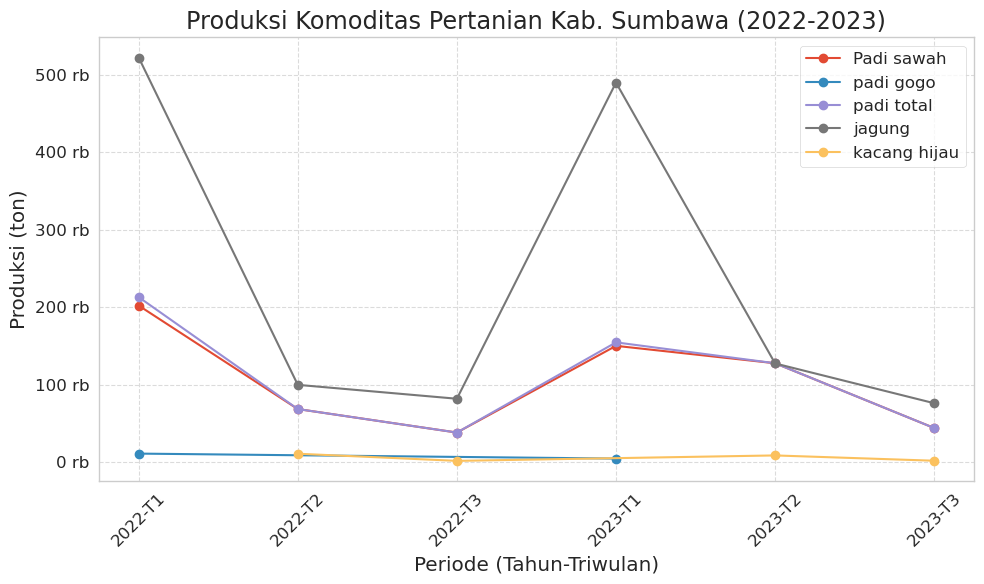

In [13]:
from matplotlib.ticker import FuncFormatter

def thousand_formatter(x, pos):
    return f'{x/1000:,.0f} rb'
formatter = FuncFormatter(thousand_formatter)

# 1. Grafik Produksi Per Komoditas per Tahun
plt.figure(figsize=(10, 6), tight_layout=True)
# Gabungkan tahun dan triwulan untuk sumbu x
df['periode'] = df['tahun'].astype(str) + "-T" + df['triwulan'].astype(str)
# Plot untuk setiap komoditas
for komoditas in df['Komoditi'].unique().to_pandas():
    komoditas_df = df[df['Komoditi'] == komoditas]
    plt.plot(komoditas_df['periode'], komoditas_df['Produksi'], 'o-', label=komoditas)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Produksi Komoditas Pertanian Kab. Sumbawa (2022-2023)')
plt.xlabel('Periode (Tahun-Triwulan)')
plt.ylabel('Produksi (ton)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

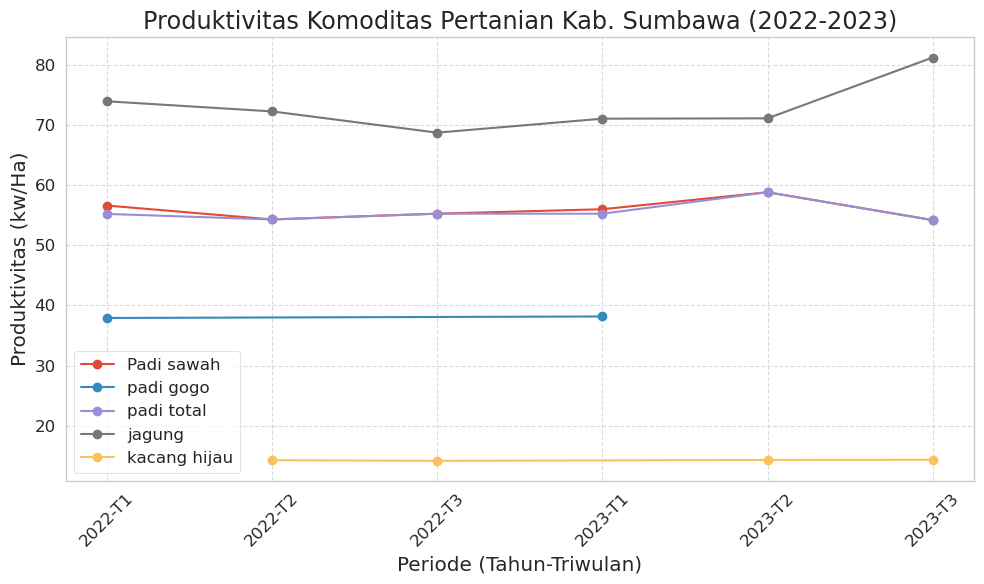

In [14]:
# 1. Grafik Produksi Per Komoditas per Tahun
plt.figure(figsize=(10, 6), tight_layout=True)
# Gabungkan tahun dan triwulan untuk sumbu x
df['periode'] = df['tahun'].astype(str) + "-T" + df['triwulan'].astype(str)
# Plot untuk setiap komoditas
for komoditas in df['Komoditi'].unique().to_pandas():
    komoditas_df = df[df['Komoditi'] == komoditas]
    plt.plot(komoditas_df['periode'], komoditas_df['Produktivitas'], 'o-', label=komoditas)
plt.title('Produktivitas Komoditas Pertanian Kab. Sumbawa (2022-2023)')
plt.xlabel('Periode (Tahun-Triwulan)')
plt.ylabel('Produktivitas (kw/Ha)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

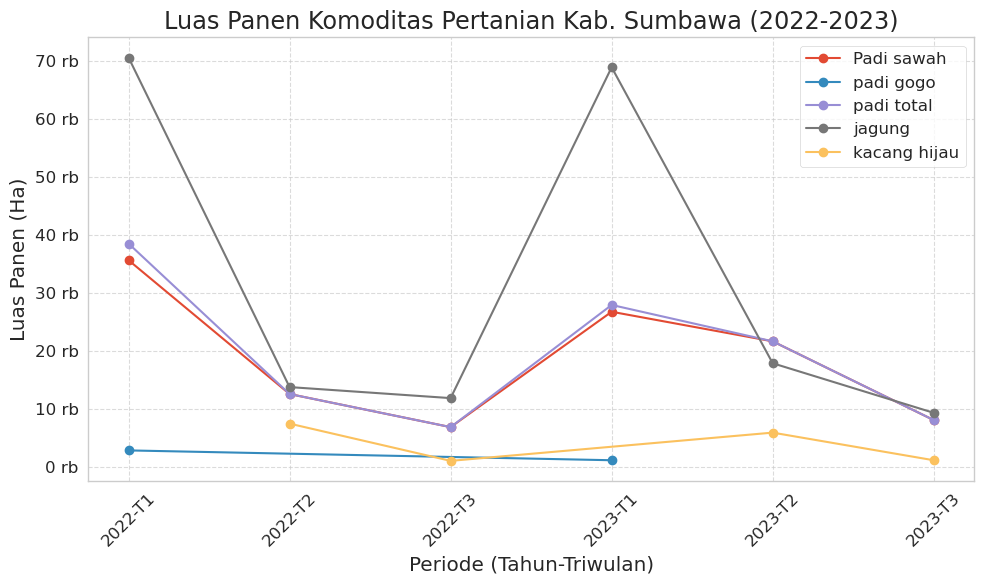

In [15]:
# 1. Grafik Produksi Per Komoditas per Tahun
plt.figure(figsize=(10, 6), tight_layout=True)
# Gabungkan tahun dan triwulan untuk sumbu x
df['periode'] = df['tahun'].astype(str) + "-T" + df['triwulan'].astype(str)
# Plot untuk setiap komoditas
for komoditas in df['Komoditi'].unique().to_pandas():
    komoditas_df = df[df['Komoditi'] == komoditas]
    plt.plot(komoditas_df['periode'], komoditas_df['Luas Panen'], 'o-', label=komoditas)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Luas Panen Komoditas Pertanian Kab. Sumbawa (2022-2023)')
plt.xlabel('Periode (Tahun-Triwulan)')
plt.ylabel('Luas Panen (Ha)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 3. Data Preparation
- Bersihkan data harga (hapus simbol, format, dan konversi ke float)
- Ekstrak fitur temporal (Tahun, Bulan, Triwulan)
- Gabungkan data harga dengan data triwulan

#  Membersihkan dataset


Memeriksa variabel serta type data nya

In [16]:
harga_df['Periode'] = '0'

In [17]:
q1_2022_start = pd.to_datetime('2022-01-01')
q1_2022_end = pd.to_datetime('2022-04-30')

q2_2022_start = pd.to_datetime('2022-05-01')
q2_2022_end = pd.to_datetime('2022-08-31')

q3_2022_start = pd.to_datetime('2022-09-01')
q3_2022_end = pd.to_datetime('2022-12-31')

q1_2023_start = pd.to_datetime('2023-01-01')
q1_2023_end = pd.to_datetime('2023-04-30')

q2_2023_start = pd.to_datetime('2023-05-01')
q2_2023_end = pd.to_datetime('2023-08-31')

q3_2023_start = pd.to_datetime('2023-09-01')
q3_2023_end = pd.to_datetime('2023-12-31')

q1_2024_start = pd.to_datetime('2024-01-01')
q1_2024_end = pd.to_datetime('2024-04-30')

q2_2024_start = pd.to_datetime('2024-05-01')
q2_2024_end = pd.to_datetime('2024-08-31')

q3_2024_start = pd.to_datetime('2024-09-01')
q3_2024_end = pd.to_datetime('2024-12-31')

In [18]:
harga_df.loc[(harga_df['Tanggal'] >= q1_2022_start) & (harga_df['Tanggal'] <= q1_2022_end), 'Periode'] = 'Q1-2022'
harga_df.loc[(harga_df['Tanggal'] >= q2_2022_start) & (harga_df['Tanggal'] <= q2_2022_end), 'Periode'] = 'Q2-2022'
harga_df.loc[(harga_df['Tanggal'] >= q3_2022_start) & (harga_df['Tanggal'] <= q3_2022_end), 'Periode'] = 'Q3-2022'

harga_df.loc[(harga_df['Tanggal'] >= q1_2023_start) & (harga_df['Tanggal'] <= q1_2023_end), 'Periode'] = 'Q1-2023'
harga_df.loc[(harga_df['Tanggal'] >= q2_2023_start) & (harga_df['Tanggal'] <= q2_2023_end), 'Periode'] = 'Q2-2023'
harga_df.loc[(harga_df['Tanggal'] >= q3_2023_start) & (harga_df['Tanggal'] <= q3_2023_end), 'Periode'] = 'Q3-2023'

harga_df.loc[(harga_df['Tanggal'] >= q1_2024_start) & (harga_df['Tanggal'] <= q1_2024_end), 'Periode'] = 'Q1-2024'
harga_df.loc[(harga_df['Tanggal'] >= q2_2024_start) & (harga_df['Tanggal'] <= q2_2024_end), 'Periode'] = 'Q2-2024'
harga_df.loc[(harga_df['Tanggal'] >= q3_2024_start) & (harga_df['Tanggal'] <= q3_2024_end), 'Periode'] = 'Q3-2024'

In [19]:
triwulan_df['Tipe'] = 'Undefined'

In [20]:
harga_df['Tipe'] = 'Undefined'

In [21]:
harga_df['Komoditi'] = harga_df['Komoditi'].replace('Jagung Pipil Kering', 'Jagung')

In [22]:
triwulan_df.loc[(triwulan_df['Komoditi'] == 'Padi sawah'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi gogo'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi total'), 'Tipe'] = 'Padi'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'jagung'), 'Tipe'] = 'Jagung'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'kacang hijau'), 'Tipe'] = 'Kacang Hijau'

harga_df.loc[(harga_df['Komoditi'] == 'Beras Medium'), 'Tipe'] = 'Padi'
harga_df.loc[(harga_df['Komoditi'] == 'Beras Premium'), 'Tipe'] = 'Padi'
harga_df.loc[(harga_df['Komoditi'] == 'Jagung'), 'Tipe'] = 'Jagung'
harga_df.loc[(harga_df['Komoditi'] == 'Kacang Hijau'), 'Tipe'] = 'Kacang Hijau'

In [23]:
triwulan_df['Periode'] = "Q" + triwulan_df['triwulan'].astype(str) + "-" + triwulan_df['tahun'].astype(str)

In [24]:
triwulan_df

,Komoditi,tahun,triwulan,Luas Panen,Produktivitas,Produksi,Tipe,Periode
0,Padi sawah,2022,1,35685.62000,56.593625,201957.860000,Padi sawah,Q1-2022
1,Padi sawah,2022,2,12599.00000,54.279752,68387.060000,Padi sawah,Q2-2022
2,Padi sawah,2022,3,6888.78970,55.240632,38054.110000,Padi sawah,Q3-2022
3,Padi sawah,2023,1,26790.36060,55.977470,149965.660000,Padi sawah,Q1-2023
4,Padi sawah,2023,2,21687.80440,58.797478,127518.820000,Padi sawah,Q2-2023
5,Padi sawah,2023,3,8101.28240,54.176608,43890.000000,Padi sawah,Q3-2023
6,padi gogo,2022,1,2871.00000,37.925865,10888.515770,Padi sawah,Q1-2022
7,padi gogo,2022,2,0.00000,0.000000,0.000000,Padi sawah,Q2-2022
8,padi gogo,2022,3,0.00000,0.000000,0.000000,Padi sawah,Q3-2022
9,padi gogo,2023,1,1175.00000,38.176791,4485.772933,Padi sawah,Q1-2023


In [25]:
harga_df.info()
triwulan_df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Komoditi        4382 non-null   object
 1   Tanggal         4382 non-null   datetime64[ns]
 2   Harga Petani    2942 non-null   float64
 3   Harga Pengecer  2943 non-null   float64
 4   Bulan           4382 non-null   int16
 5   Periode         4382 non-null   object
 6   Tipe            4382 non-null   object
dtypes: datetime64[ns](1), float64(2), int16(1), object(3)
memory usage: 267.5+ KB
<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Komoditi       30 non-null     object
 1   tahun          30 non-null     int64
 2   triwulan       30 non-null     int64
 3   Luas Panen     30 non-null     float64
 4   Produktivitas  30 non-null     float64
 5 

In [26]:
explore_harga_data(harga_df)

1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani             float64
Harga Pengecer           float64
Bulan                      int16
Periode                   object
Tipe                      object
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      1440
Harga Pengecer    1439
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer  \
count                           4382   2942.000000     2943.000000   
mean   2023-07-02 17:59:30.424463616   9954.928620    11163.098879   
min              2022-01-01 00:00:00   3300.000000     3600.000000   
25%    2022-10-02 00:00:00.000000000   8200.000000     9000.000000   
50%    2023-07-03 00:00:00.000000000  10500.000000    11500.000000   
75%    2024-04-01 18:00:00.000000000  13000.000000    15000.000000   
max              2024-12-31 00:00:00  15500.000000    17500.000000   
std                  

Karena untuk data harga memiliki missing value, maka akan dilakukan handling missing value dengan interpolate linear

In [27]:
harga_df_setelah = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

In [28]:
harga_df_setelah['Harga Petani'] = harga_df_setelah['Harga Petani'].interpolate(method='linear')
harga_df_setelah['Harga Pengecer'] = harga_df_setelah['Harga Pengecer'].interpolate(method='linear')

In [29]:
print(harga_df_setelah.isnull().sum())

Komoditi          0
Tanggal           0
Harga Petani      0
Harga Pengecer    0
Bulan             0
Periode           0
Tipe              0
dtype: int64


In [30]:
top_commodities = harga_df_setelah['Komoditi'].value_counts().head(5).index.to_pandas()
top_commodities

Index(['Beras Premium', 'Kacang Hijau', 'Beras Medium', 'Jagung'], dtype='object', name='Komoditi')

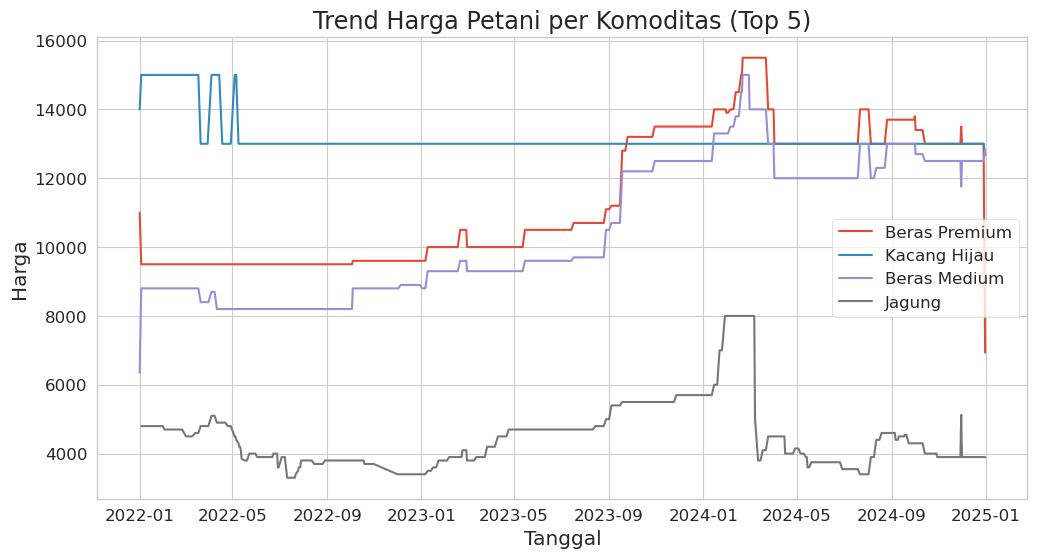

In [31]:
plt.figure(figsize=(12, 6))

for commodity in top_commodities:
    subset = harga_df_setelah[harga_df_setelah['Komoditi'] == commodity]
    
    if subset.empty:
        print(f"No data for commodity: {commodity}")
        continue

    try:
        sns.lineplot(
            x=subset['Tanggal'].to_pandas(),
            y=subset['Harga Petani'].to_pandas(),
            label=commodity
        )
    except KeyError as e:
        print(f"KeyError: {e} for commodity: {commodity}")

plt.title('Trend Harga Petani per Komoditas (Top 5)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()


In [32]:
harga_df_setelah

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe
0,Jagung,2022-01-03,4800.0,5000.0,1,Q1-2022,Jagung
1,Jagung,2022-01-04,4800.0,5000.0,1,Q1-2022,Jagung
2,Jagung,2022-01-05,4800.0,5000.0,1,Q1-2022,Jagung
3,Jagung,2022-01-06,4800.0,5000.0,1,Q1-2022,Jagung
4,Jagung,2022-01-07,4800.0,5000.0,1,Q1-2022,Jagung
...,...,...,...,...,...,...,...
4377,Jagung,2024-12-27,3900.0,4000.0,12,Q3-2024,Jagung
4378,Jagung,2024-12-28,3900.0,4000.0,12,Q3-2024,Jagung
4379,Jagung,2024-12-29,3900.0,4000.0,12,Q3-2024,Jagung
4380,Jagung,2024-12-30,3900.0,4000.0,12,Q3-2024,Jagung


In [33]:
df_outer_join = cudf.merge(harga_df_setelah, triwulan_df, on='Tipe', how='left')

In [34]:
df_outer_join

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode_x,Tipe,Komoditi_y,tahun,triwulan,Luas Panen,Produktivitas,Produksi,Periode_y
0,Jagung,2023-09-19,5500.0,5800.0,9,Q3-2023,Jagung,jagung,2022,1,70654.48313,73.898901,522128.86830,Q1-2022
1,Jagung,2023-09-19,5500.0,5800.0,9,Q3-2023,Jagung,jagung,2022,3,11893.00810,68.690000,81693.07264,Q3-2022
2,Jagung,2023-09-19,5500.0,5800.0,9,Q3-2023,Jagung,jagung,2022,2,13795.94250,72.218328,99631.98950,Q2-2022
3,Jagung,2023-09-19,5500.0,5800.0,9,Q3-2023,Jagung,jagung,2023,1,68965.86949,71.010134,489727.56110,Q1-2023
4,Jagung,2023-09-20,5500.0,5800.0,9,Q3-2023,Jagung,jagung,2022,1,70654.48313,73.898901,522128.86830,Q1-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26287,Beras Medium,2024-12-14,12500.0,13500.0,12,Q3-2024,Padi,padi total,2023,1,27965.36060,55.229552,154451.43290,Q1-2023
26288,Beras Medium,2024-12-15,12500.0,13500.0,12,Q3-2024,Padi,padi total,2022,1,38556.62000,55.203588,212846.37580,Q1-2022
26289,Beras Medium,2024-12-15,12500.0,13500.0,12,Q3-2024,Padi,padi total,2022,3,6888.78970,55.240632,38054.11000,Q3-2022
26290,Beras Medium,2024-12-15,12500.0,13500.0,12,Q3-2024,Padi,padi total,2022,2,12599.00000,54.279752,68387.06000,Q2-2022


In [35]:
merged_df = cudf.merge(
    harga_df_setelah,
    triwulan_df,
    left_on=['Periode', 'Tipe'], # Kolom dari df_penjualan
    right_on=['Periode', 'Tipe'],       # Kolom dari df_kehadiran
    how='left'                               # Pilih jenis join sesuai kebutuhanmu
)

In [36]:
merged_df

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,Komoditi_y,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Beras Medium,2024-08-11,12200.0,13266.666667,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Beras Medium,2024-08-12,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Beras Medium,2024-08-13,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Beras Medium,2024-08-14,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Beras Medium,2024-08-15,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,Jagung,2022-09-11,3800.0,3900.000000,9,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264
4378,Jagung,2022-09-12,3800.0,3900.000000,9,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264
4379,Jagung,2022-09-13,3800.0,3900.000000,9,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264
4380,Jagung,2022-09-14,3800.0,3900.000000,9,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264


In [37]:
merged_df = merged_df.drop(columns=['Komoditi_y'])

In [38]:
merged_df

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Beras Medium,2024-08-11,12200.0,13266.666667,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>
1,Beras Medium,2024-08-12,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>
2,Beras Medium,2024-08-13,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>
3,Beras Medium,2024-08-14,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>
4,Beras Medium,2024-08-15,12300.0,13300.000000,8,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
4377,Jagung,2022-09-11,3800.0,3900.000000,9,Q3-2022,Jagung,2022,3,11893.0081,68.69,81693.07264
4378,Jagung,2022-09-12,3800.0,3900.000000,9,Q3-2022,Jagung,2022,3,11893.0081,68.69,81693.07264
4379,Jagung,2022-09-13,3800.0,3900.000000,9,Q3-2022,Jagung,2022,3,11893.0081,68.69,81693.07264
4380,Jagung,2022-09-14,3800.0,3900.000000,9,Q3-2022,Jagung,2022,3,11893.0081,68.69,81693.07264


## 4. Modeling
- Siapkan data untuk pelatihan (normalisasi, pembagian train-test)
- Bangun model LSTM
- Latih model dengan data pelatihan

In [39]:
merged_df=merged_df.sort_values(by='Tanggal')
merged_df=merged_df.reset_index()
merged_df=merged_df.drop(columns=['index'])

In [40]:
train_data = merged_df[(merged_df['Tanggal'].dt.year >= 2022) & (merged_df['Tanggal'].dt.year <= 2023)]
test_data = merged_df[merged_df['Tanggal'].dt.year == 2024]

In [41]:
test_data=test_data.sort_values(by='Tanggal')
test_data=test_data.reset_index()
test_data=test_data.drop(columns=['index'])

In [42]:
train_data.head()

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Beras Medium,2022-01-01,6350.0,6500.0,1,Q1-2022,Padi,2022,1,38556.62,55.203588,212846.3758
1,Beras Premium,2022-01-01,11000.0,11750.0,1,Q1-2022,Padi,2022,1,38556.62,55.203588,212846.3758
2,Kacang Hijau,2022-01-01,14000.0,15500.0,1,Q1-2022,Kacang Hijau,2022,1,0.00,0.000000,0.0000
3,Beras Medium,2022-01-02,7575.0,7750.0,1,Q1-2022,Padi,2022,1,38556.62,55.203588,212846.3758
4,Beras Premium,2022-01-02,10250.0,10875.0,1,Q1-2022,Padi,2022,1,38556.62,55.203588,212846.3758


In [43]:
print("Data Train:")
print(train_data.head())
print("\nData Test:")
print(test_data.head())

Data Train:
      Komoditi_x    Tanggal  Harga Petani  Harga Pengecer  Bulan  Periode  \
0   Beras Medium 2022-01-01        6350.0          6500.0      1  Q1-2022   
1  Beras Premium 2022-01-01       11000.0         11750.0      1  Q1-2022   
2   Kacang Hijau 2022-01-01       14000.0         15500.0      1  Q1-2022   
3   Beras Medium 2022-01-02        7575.0          7750.0      1  Q1-2022   
4  Beras Premium 2022-01-02       10250.0         10875.0      1  Q1-2022   

           Tipe  tahun  triwulan  Luas Panen  Produktivitas     Produksi  
0          Padi   2022         1    38556.62      55.203588  212846.3758  
1          Padi   2022         1    38556.62      55.203588  212846.3758  
2  Kacang Hijau   2022         1        0.00       0.000000       0.0000  
3          Padi   2022         1    38556.62      55.203588  212846.3758  
4          Padi   2022         1    38556.62      55.203588  212846.3758  

Data Test:
      Komoditi_x    Tanggal  Harga Petani  Harga Pengecer  Bula

In [44]:
train_data

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Beras Medium,2022-01-01,6350.0,6500.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
1,Beras Premium,2022-01-01,11000.0,11750.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
2,Kacang Hijau,2022-01-01,14000.0,15500.0,1,Q1-2022,Kacang Hijau,2022,1,0.0000,0.000000,0.000000
3,Beras Medium,2022-01-02,7575.0,7750.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
4,Beras Premium,2022-01-02,10250.0,10875.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
...,...,...,...,...,...,...,...,...,...,...,...,...
2913,Kacang Hijau,2023-12-30,13000.0,17000.0,12,Q3-2023,Kacang Hijau,2023,3,1172.3886,14.395695,1687.734887
2914,Beras Medium,2023-12-31,12500.0,13800.0,12,Q3-2023,Padi,2023,3,8101.2824,54.176608,43890.000000
2915,Jagung,2023-12-31,5700.0,6000.0,12,Q3-2023,Jagung,2023,3,9353.0426,81.165084,75914.049070
2916,Beras Premium,2023-12-31,13500.0,14600.0,12,Q3-2023,Padi,2023,3,8101.2824,54.176608,43890.000000


In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [46]:
train_data

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Beras Medium,2022-01-01,6350.0,6500.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
1,Beras Premium,2022-01-01,11000.0,11750.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
2,Kacang Hijau,2022-01-01,14000.0,15500.0,1,Q1-2022,Kacang Hijau,2022,1,0.0000,0.000000,0.000000
3,Beras Medium,2022-01-02,7575.0,7750.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
4,Beras Premium,2022-01-02,10250.0,10875.0,1,Q1-2022,Padi,2022,1,38556.6200,55.203588,212846.375800
...,...,...,...,...,...,...,...,...,...,...,...,...
2913,Kacang Hijau,2023-12-30,13000.0,17000.0,12,Q3-2023,Kacang Hijau,2023,3,1172.3886,14.395695,1687.734887
2914,Beras Medium,2023-12-31,12500.0,13800.0,12,Q3-2023,Padi,2023,3,8101.2824,54.176608,43890.000000
2915,Jagung,2023-12-31,5700.0,6000.0,12,Q3-2023,Jagung,2023,3,9353.0426,81.165084,75914.049070
2916,Beras Premium,2023-12-31,13500.0,14600.0,12,Q3-2023,Padi,2023,3,8101.2824,54.176608,43890.000000


In [47]:
kolom_scale = ['Harga Petani', 'Harga Pengecer', 'Luas Panen', 'Produktivitas', 'Produksi']
data_scaling = train_data[kolom_scale]

In [48]:
data_scaling

,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi
0,6350.0,6500.0,38556.6200,55.203588,212846.375800
1,11000.0,11750.0,38556.6200,55.203588,212846.375800
2,14000.0,15500.0,0.0000,0.000000,0.000000
3,7575.0,7750.0,38556.6200,55.203588,212846.375800
4,10250.0,10875.0,38556.6200,55.203588,212846.375800
...,...,...,...,...,...
2913,13000.0,17000.0,1172.3886,14.395695,1687.734887
2914,12500.0,13800.0,8101.2824,54.176608,43890.000000
2915,5700.0,6000.0,9353.0426,81.165084,75914.049070
2916,13500.0,14600.0,8101.2824,54.176608,43890.000000


In [49]:
scaled_data_numpy = scaler.fit_transform(data_scaling.to_numpy())

In [50]:
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']

In [51]:
scaled_df_cudf = cudf.DataFrame(scaled_data_numpy, columns=nama_kolom_scaled_baru)

In [52]:
scaled_df_cudf

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.260684,0.216418,0.545707,0.680140,0.407651
1,0.658120,0.608209,0.545707,0.680140,0.407651
2,0.914530,0.888060,0.000000,0.000000,0.000000
3,0.365385,0.309701,0.545707,0.680140,0.407651
4,0.594017,0.542910,0.545707,0.680140,0.407651
...,...,...,...,...,...
2913,0.829060,1.000000,0.016593,0.177363,0.003232
2914,0.786325,0.761194,0.114661,0.667487,0.084060
2915,0.205128,0.179104,0.132377,1.000000,0.145393
2916,0.871795,0.820896,0.114661,0.667487,0.084060


In [53]:
train_data_normalisasi=train_data
train_data_normalisasi[nama_kolom_scaled_baru] = scaled_df_cudf

In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

In [55]:
kolom_target_encode=['Komoditi_x', 'Tipe']


In [56]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)


In [57]:
data_for_encoding_np = train_data_normalisasi[kolom_target_encode].to_numpy()

In [58]:
train_data_encoded_np = ohe.fit_transform(data_for_encoding_np)
train_data_pandas = train_data_normalisasi.to_pandas()
encoded_df_pandas = pd.DataFrame(train_data_encoded_np, columns=ohe.get_feature_names_out(kolom_target_encode))
df_encoded_pandas = pd.concat([train_data_pandas, encoded_df_pandas], axis=1)

In [59]:
df_encoded_pandas

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,tahun,triwulan,Luas Panen,...,luas_panen_scaled,produktivitas_scaled,produksi_scaled,Komoditi_x_Beras Medium,Komoditi_x_Beras Premium,Komoditi_x_Jagung,Komoditi_x_Kacang Hijau,Tipe_Jagung,Tipe_Kacang Hijau,Tipe_Padi
0,Beras Medium,2022-01-01,6350.0,6500.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Beras Premium,2022-01-01,11000.0,11750.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,Kacang Hijau,2022-01-01,14000.0,15500.0,1,Q1-2022,Kacang Hijau,2022,1,0.0000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,Beras Medium,2022-01-02,7575.0,7750.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Beras Premium,2022-01-02,10250.0,10875.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,Kacang Hijau,2023-12-30,13000.0,17000.0,12,Q3-2023,Kacang Hijau,2023,3,1172.3886,...,0.016593,0.177363,0.003232,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2914,Beras Medium,2023-12-31,12500.0,13800.0,12,Q3-2023,Padi,2023,3,8101.2824,...,0.114661,0.667487,0.084060,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2915,Jagung,2023-12-31,5700.0,6000.0,12,Q3-2023,Jagung,2023,3,9353.0426,...,0.132377,1.000000,0.145393,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2916,Beras Premium,2023-12-31,13500.0,14600.0,12,Q3-2023,Padi,2023,3,8101.2824,...,0.114661,0.667487,0.084060,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [60]:
train_data_siap = cudf.DataFrame(df_encoded_pandas)

In [61]:
train_data_siap

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Bulan,Periode,Tipe,tahun,triwulan,Luas Panen,...,luas_panen_scaled,produktivitas_scaled,produksi_scaled,Komoditi_x_Beras Medium,Komoditi_x_Beras Premium,Komoditi_x_Jagung,Komoditi_x_Kacang Hijau,Tipe_Jagung,Tipe_Kacang Hijau,Tipe_Padi
0,Beras Medium,2022-01-01,6350.0,6500.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Beras Premium,2022-01-01,11000.0,11750.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,Kacang Hijau,2022-01-01,14000.0,15500.0,1,Q1-2022,Kacang Hijau,2022,1,0.0000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,Beras Medium,2022-01-02,7575.0,7750.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Beras Premium,2022-01-02,10250.0,10875.0,1,Q1-2022,Padi,2022,1,38556.6200,...,0.545707,0.680140,0.407651,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,Kacang Hijau,2023-12-30,13000.0,17000.0,12,Q3-2023,Kacang Hijau,2023,3,1172.3886,...,0.016593,0.177363,0.003232,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2914,Beras Medium,2023-12-31,12500.0,13800.0,12,Q3-2023,Padi,2023,3,8101.2824,...,0.114661,0.667487,0.084060,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2915,Jagung,2023-12-31,5700.0,6000.0,12,Q3-2023,Jagung,2023,3,9353.0426,...,0.132377,1.000000,0.145393,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2916,Beras Premium,2023-12-31,13500.0,14600.0,12,Q3-2023,Padi,2023,3,8101.2824,...,0.114661,0.667487,0.084060,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [62]:
def create_sequences(data, time_steps=60, target_col=0):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])  # Ambil semua fitur
        y.append(data[i + time_steps, target_col])  # Ambil target dari kolom tertentu
    
    return np.array(X), np.array(y)


In [63]:
train_data_siap.columns

Index(['Komoditi_x', 'Tanggal', 'Harga Petani', 'Harga Pengecer', 'Bulan',
       'Periode', 'Tipe', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas',
       'Produksi', 'harga_petani_scaled', 'harga_pengecer_scaled',
       'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled',
       'Komoditi_x_Beras Medium', 'Komoditi_x_Beras Premium',
       'Komoditi_x_Jagung', 'Komoditi_x_Kacang Hijau', 'Tipe_Jagung',
       'Tipe_Kacang Hijau', 'Tipe_Padi'],
      dtype='object')

Untuk train dengan target data harga petani

In [64]:
features = [
    'harga_petani_scaled',
    'harga_pengecer_scaled',
    'luas_panen_scaled',
    'produktivitas_scaled',
    'produksi_scaled',
    'Komoditi_x_Beras Medium',
    'Komoditi_x_Beras Premium',
    'Komoditi_x_Jagung',
    'Komoditi_x_Kacang Hijau',
    'Tipe_Jagung',
    'Tipe_Kacang Hijau',
    'Tipe_Padi'
]

In [65]:
data_for_sequences_cupy = train_data_siap[features].values
data_for_sequences_np = data_for_sequences_cupy.get()

print("Data setelah konversi ke NumPy array:")
print(data_for_sequences_np[:5])
print(f"Tipe data_for_sequences_np: {type(data_for_sequences_np)}")
print("-" * 50)

X, y = create_sequences(data_for_sequences_np, time_steps=3, target_col=0)

# --- (4) Convert X and y to NumPy if they are still CuPy (double-check) ---
# create_sequences should return NumPy, but this is a final safeguard
if isinstance(X, cp.ndarray):
    print("X is still a CuPy array. Converting to NumPy...")
    X = X.get()
if isinstance(y, cp.ndarray):
    print("y is still a CuPy array. Converting to NumPy...")
    y = y.get()


print(f"Shape of X before split: {X.shape}")
print(f"Shape of y before split: {y.shape}")
print("-" * 50)

# --- (5) Now perform the train_test_split ---
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Split successful!")
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data setelah konversi ke NumPy array:
[[0.26068376 0.21641791 0.54570663 0.6801396  0.40765104 1.
  0.         0.         0.         0.         0.         1.        ]
 [0.65811966 0.60820896 0.54570663 0.6801396  0.40765104 0.
  1.         0.         0.         0.         0.         1.        ]
 [0.91452991 0.8880597  0.         0.         0.         0.
  0.         0.         1.         0.         1.         0.        ]
 [0.36538462 0.30970149 0.54570663 0.6801396  0.40765104 1.
  0.         0.         0.         0.         0.         1.        ]
 [0.59401709 0.54291045 0.54570663 0.6801396  0.40765104 0.
  1.         0.         0.         0.         0.         1.        ]]
Tipe data_for_sequences_np: <class 'numpy.ndarray'>
--------------------------------------------------
Shape of X before split: (2915, 3, 12)
Shape of y before split: (2915,)
--------------------------------------------------
Split successful!
Shape of x_train: (2332, 3, 12)
Shape of x_test: (583, 3, 12)
Shape of y

In [66]:
import tensorflow as tf

tf.config.optimizer.set_jit(True)  # Menonaktifkan JIT compilation


In [67]:
scaler.fit(data_for_sequences_np)

MinMaxScaler()

In [68]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Membangun model LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))  # Untuk regresi, jika target adalah harga petani
model.compile(optimizer='adam', loss='mean_squared_error')

# Melatih model
model_lstm=model.fit(x_train, y_train, epochs=50, batch_size=32)

I0000 00:00:1752422011.624711   35647 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1752422011.627899   35647 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1752422011.627986   35647 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1752422011.630772   35647 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1752422011.630859   35647 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Epoch 1/50


I0000 00:00:1752422013.008805   35787 service.cc:146] XLA service 0x5c27af051770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752422013.008857   35787 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-07-13 23:53:33.025903: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90300
I0000 00:00:1752422013.063376   35787 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2839 

2025-07-13 23:53:35.002749: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1562
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0305
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0214
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0142
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0163
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0163
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0135
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0116
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0136
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0131
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0125
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0145
Epoch 13/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134
Epoch 14/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0132
Epoch 15/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0141
Epoch 16/50
73/73 ━━━━━━━━━━

## 5. Evaluation
- Evaluasi model (hitung MSE, MAPE, visualisasi hasil)
- Simpan model jika hasil memuaskan

In [70]:
loss = model.evaluate(x_test, y_test)
print(f"Loss pada data test: {loss}")   

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0060
Loss pada data test: 0.006713490933179855


In [71]:
y_pred = model.predict(x_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [74]:
y_pred_inv = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((y_pred.shape[0], data_for_sequences_np.shape[1] - 1))), axis=1))[:, 0]
y_test_inv = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], data_for_sequences_np.shape[1] - 1))), axis=1))[:, 0]


In [75]:
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

ValueError: non-broadcastable output operand with shape (583,1) doesn't match the broadcast shape (583,12)

## 6. Deployment
- Siapkan model untuk digunakan dalam aplikasi
- Buat dokumentasi penggunaan model